[287 373 351   0   0 489]
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.

c:\Users\Chi\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\plotting.py:137: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)


[0.0, 0.16, 0.051, 0.508, 0.356, 0.051, 0.358, 0.032, 0.0, 0.152, 0.446, 0.0, 0.128, 0.0, 0.254, 0.0, 0.508, 0.289, 0.274, 0.727, 0.149, 0.0, 0.0, 0.028, 0.127, 0.305]
18.9
Finished mi with 700 features
[311 238 252   0 336 363]
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf i

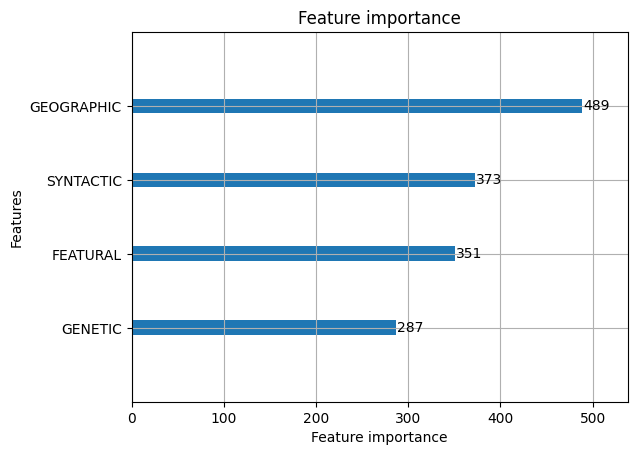

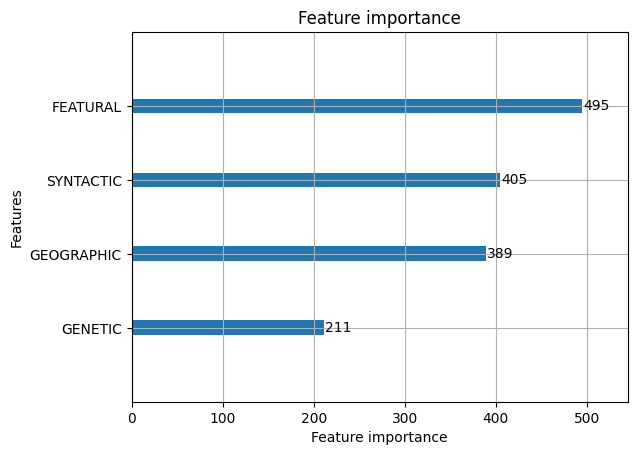

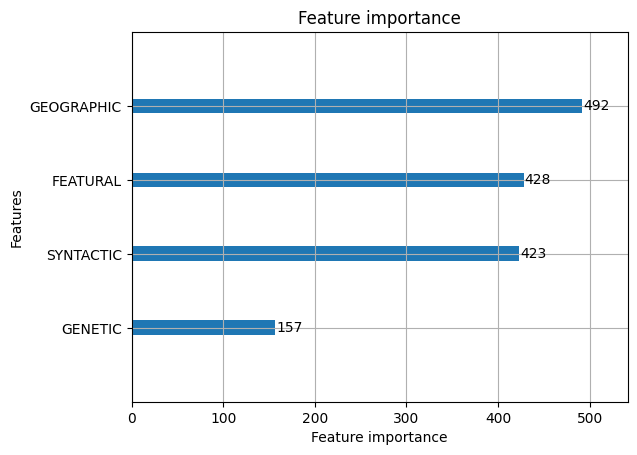

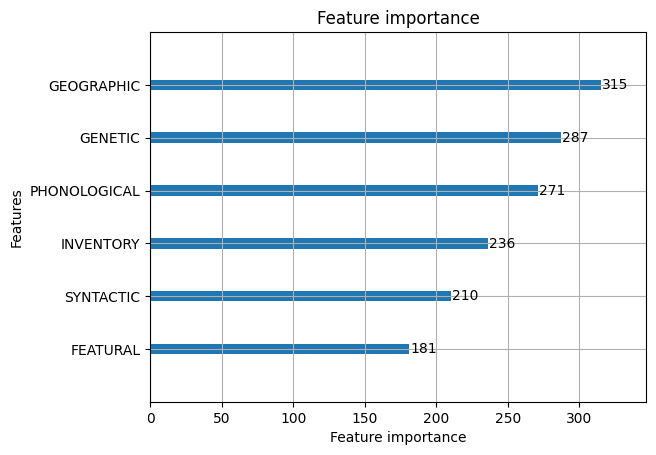

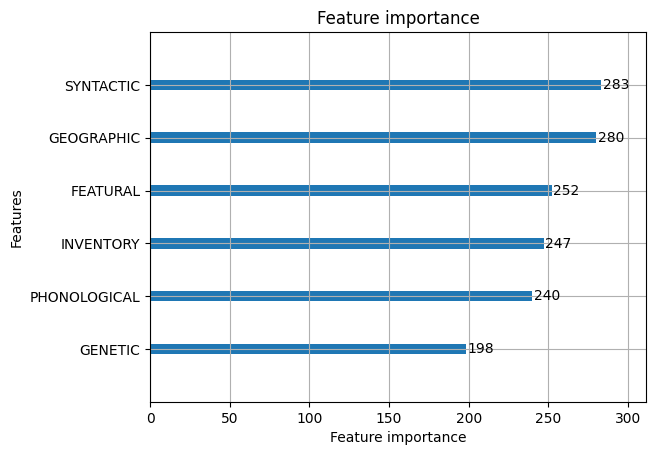

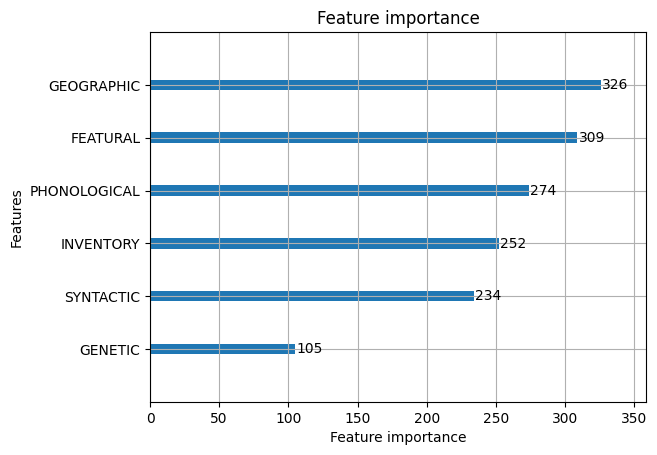

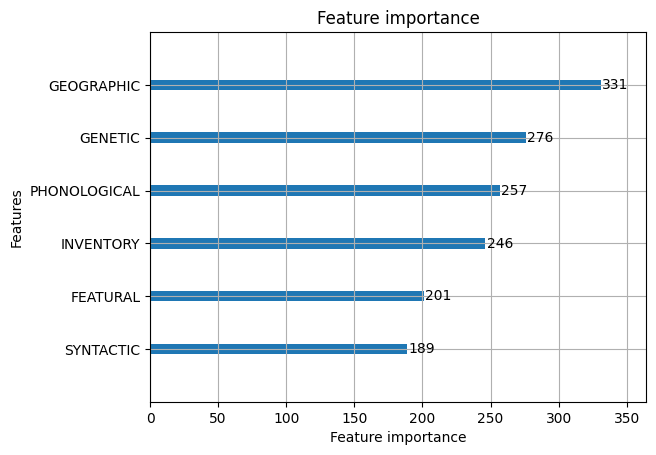

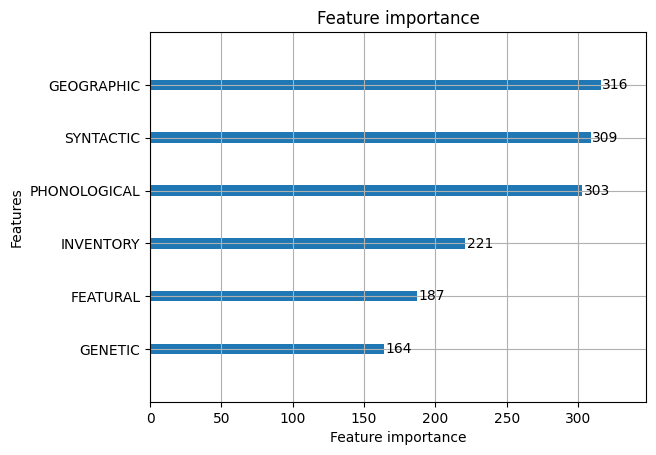

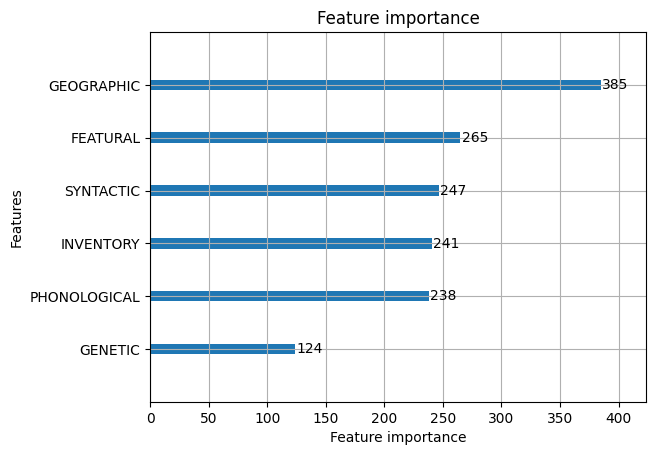

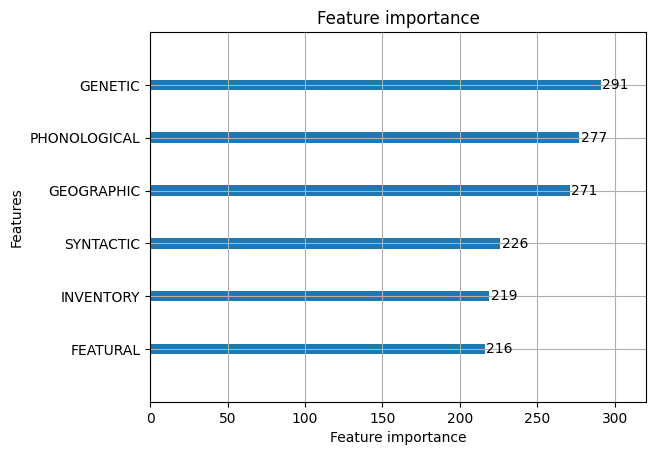

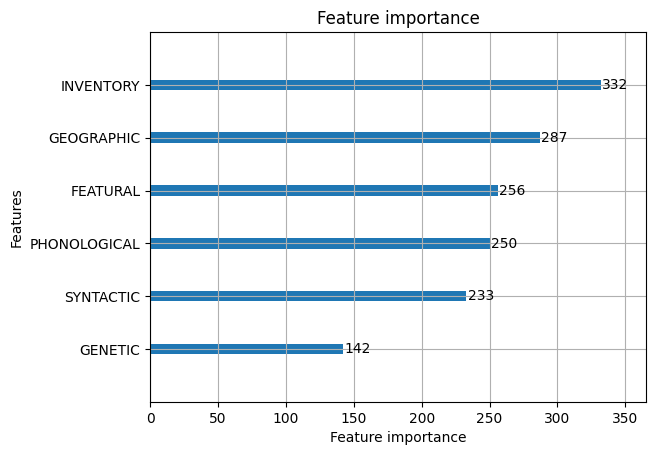

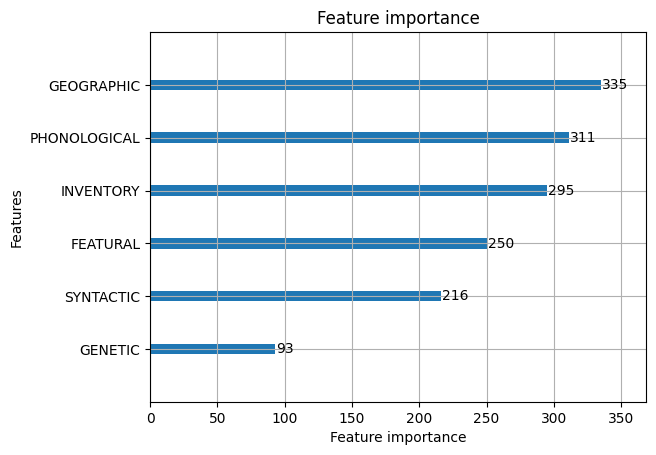

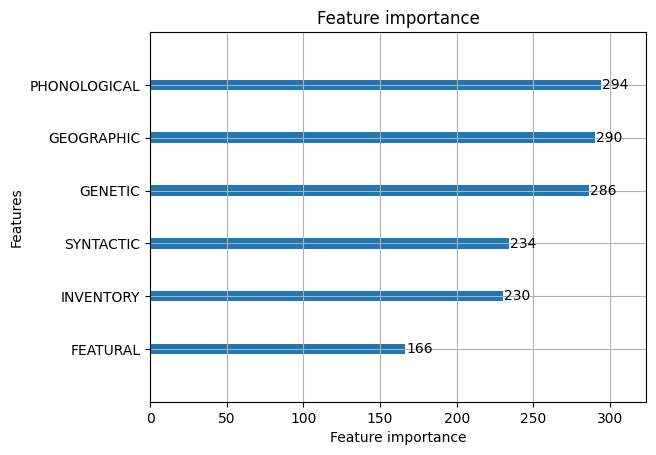

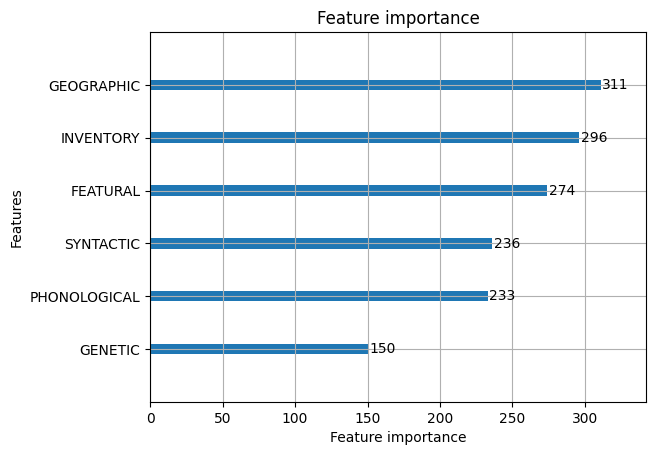

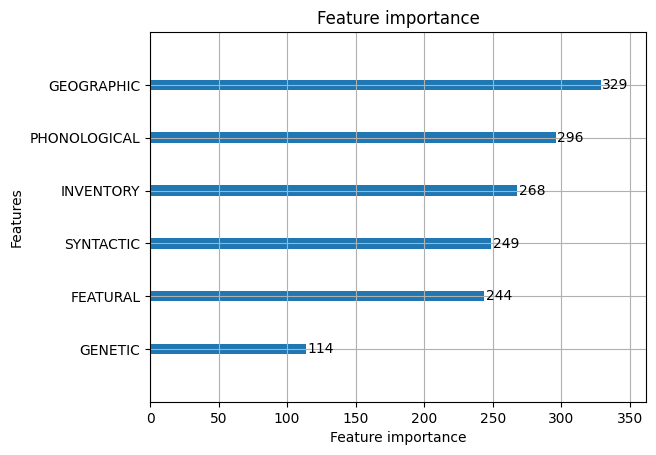

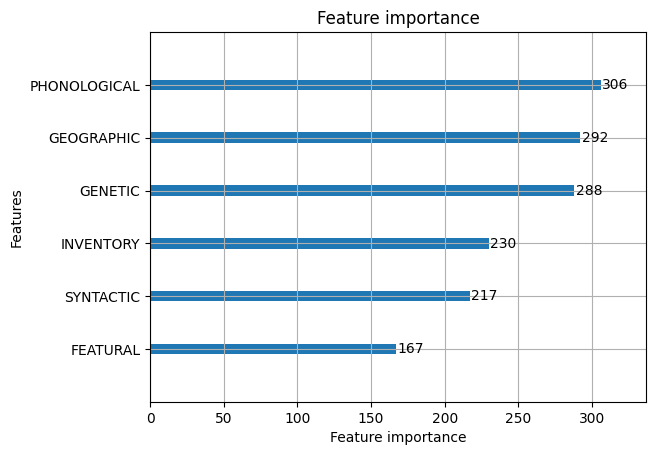

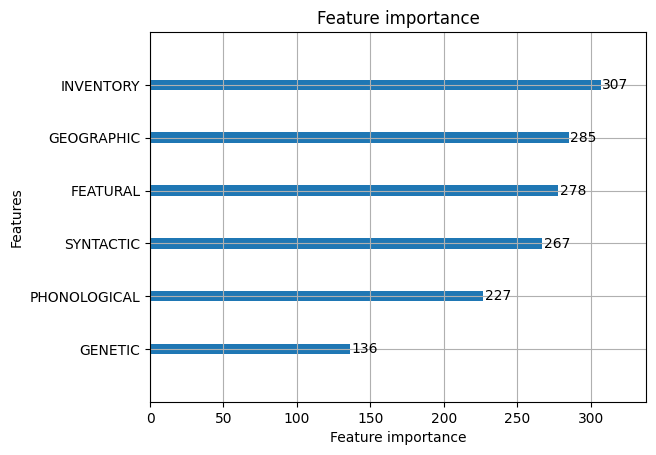

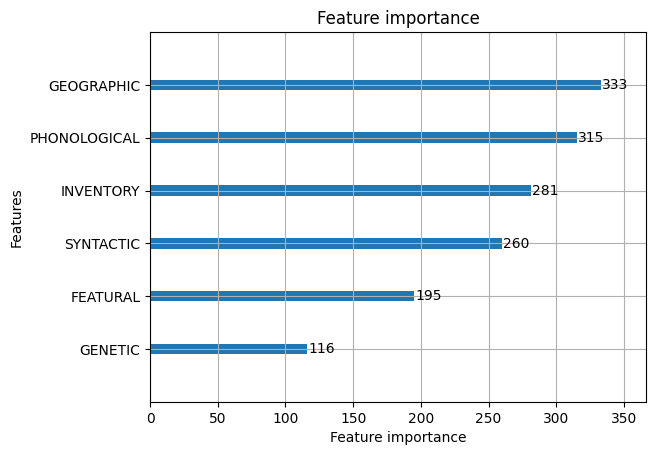

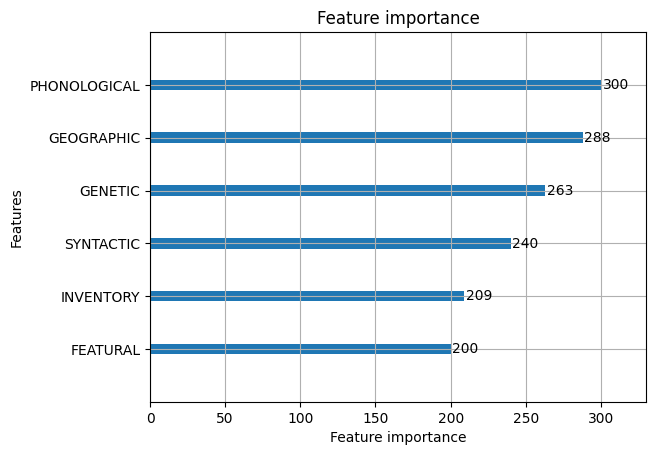

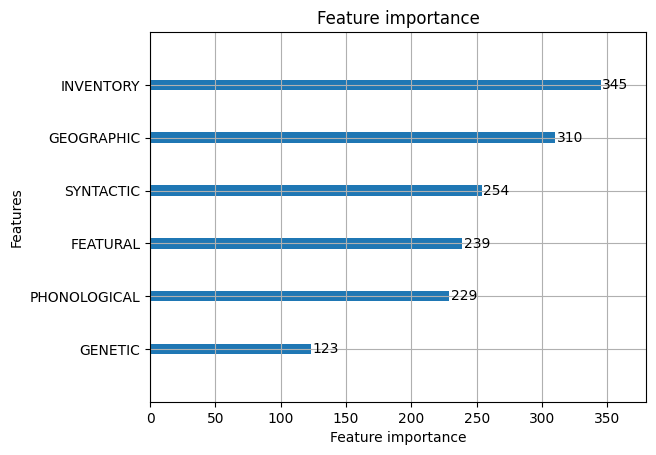

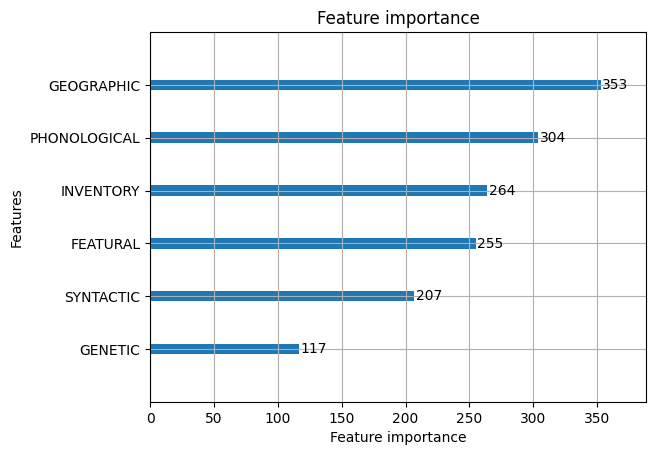

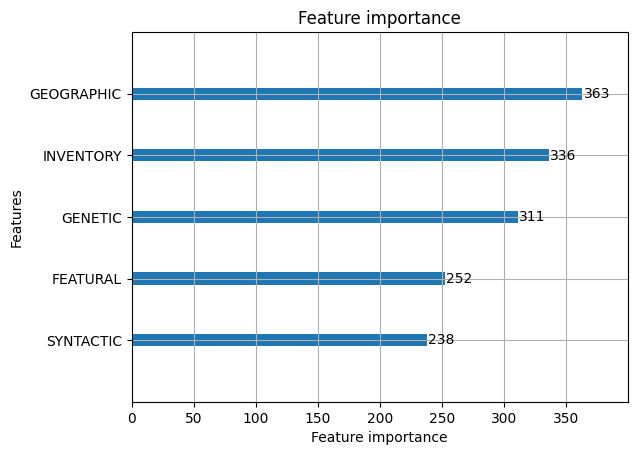

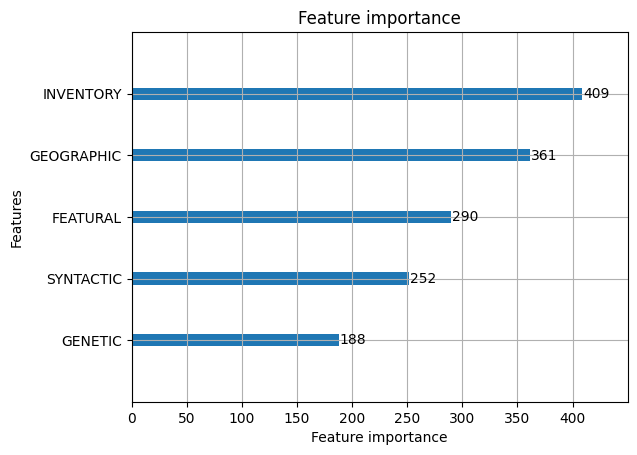

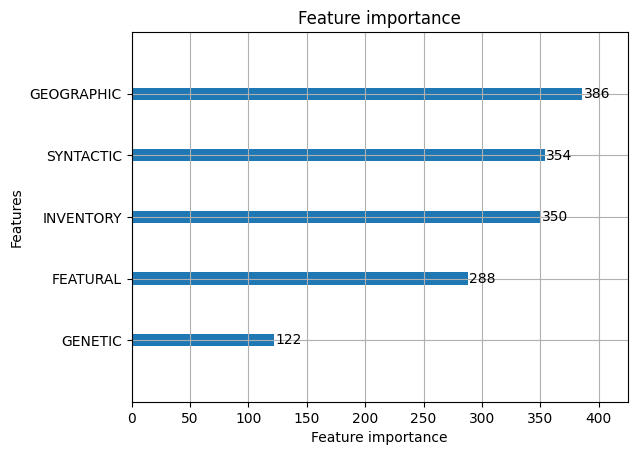

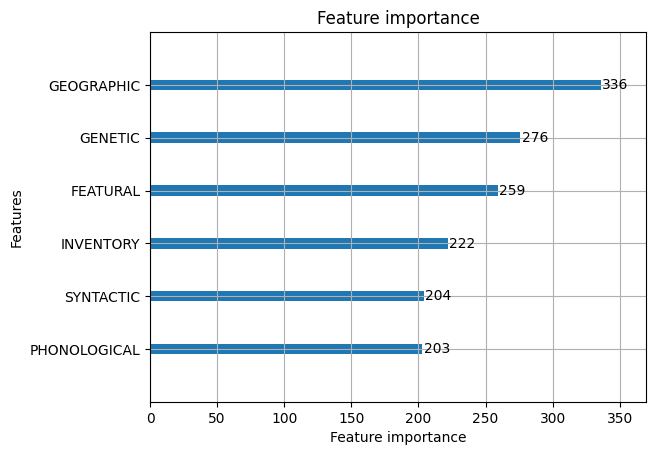

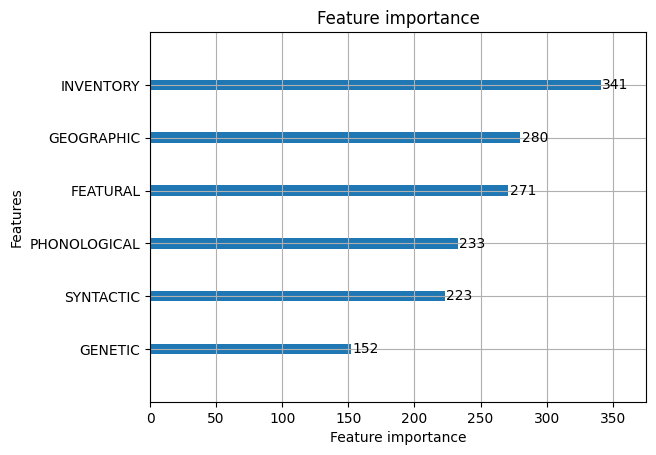

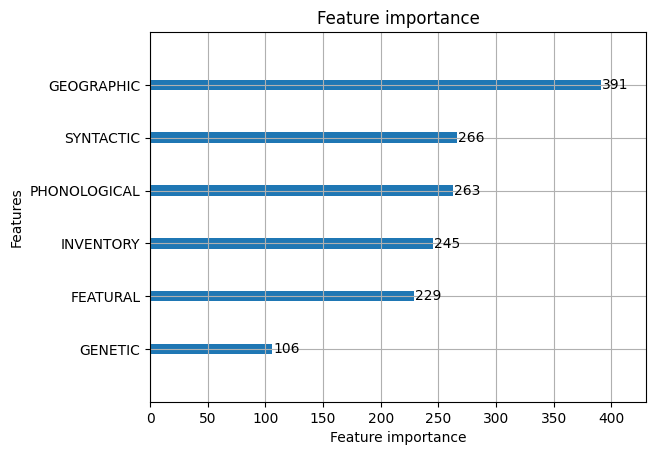

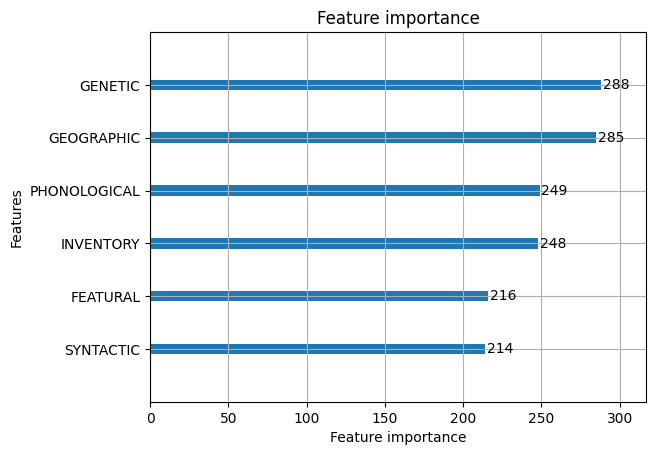

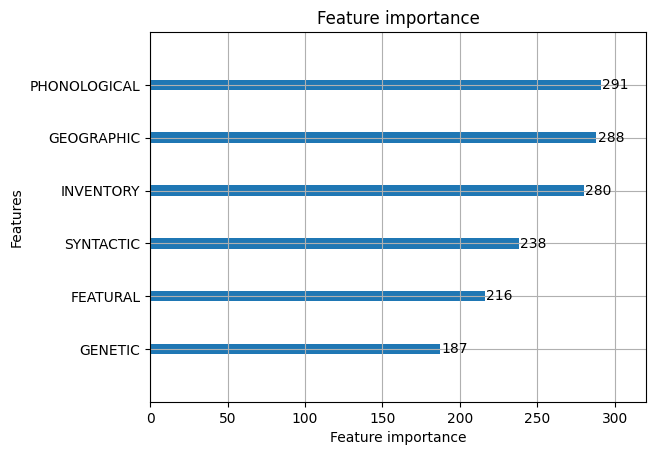

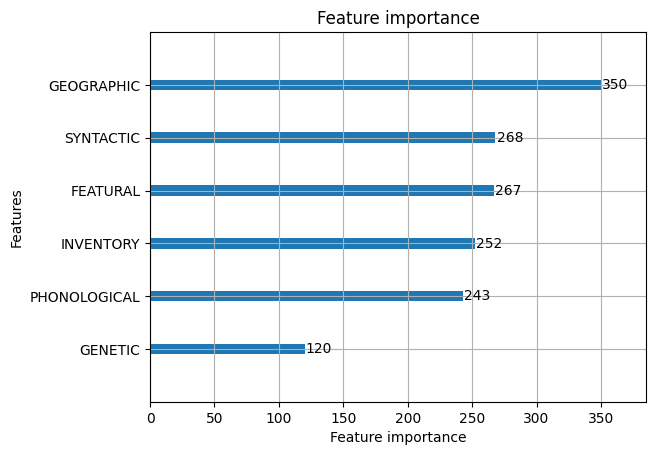

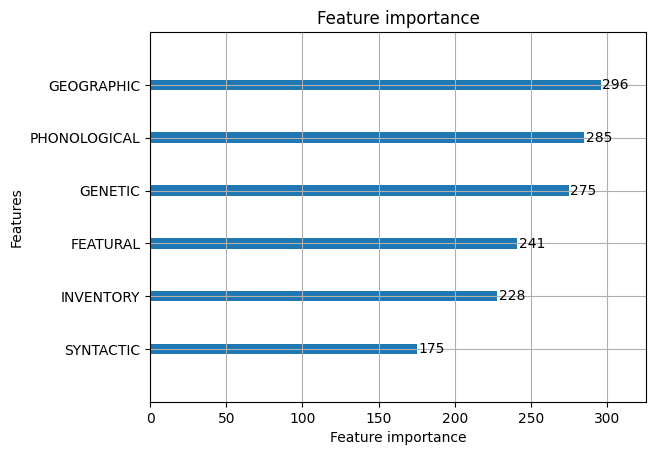

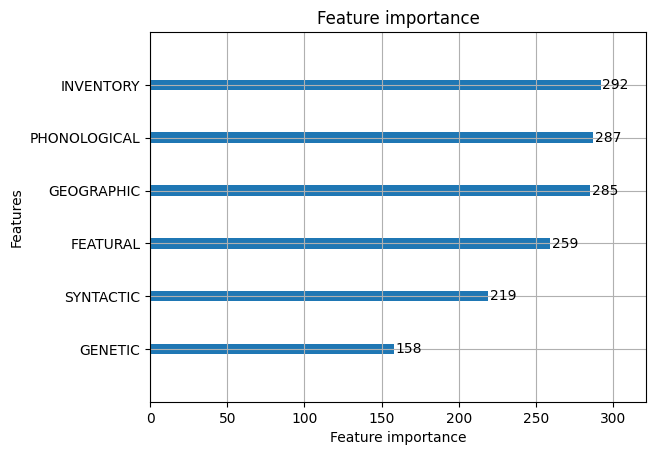

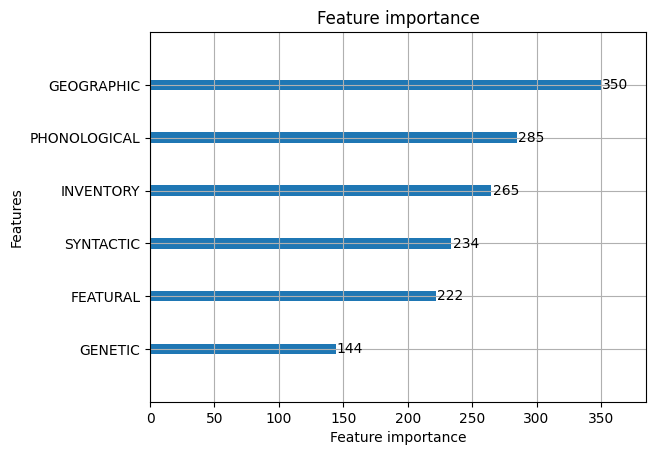

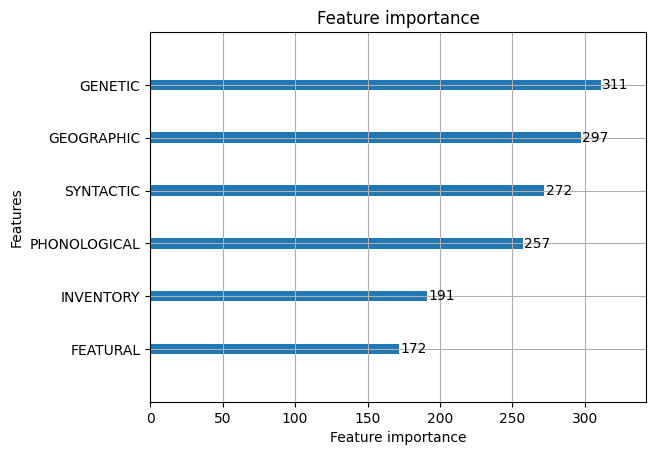

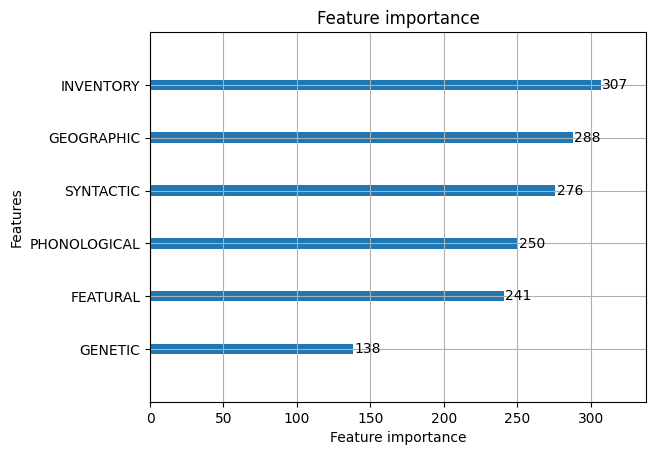

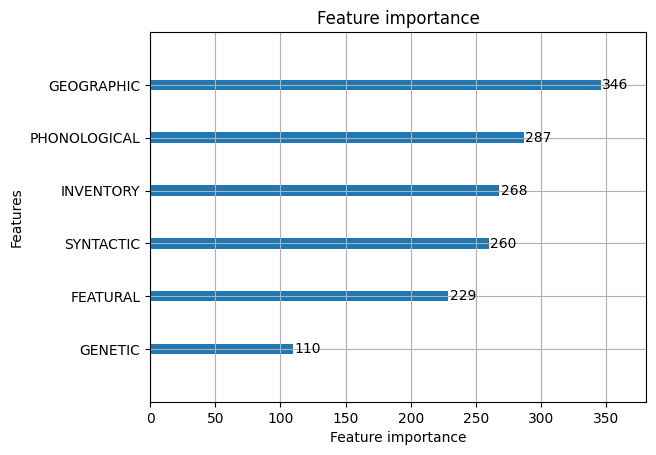

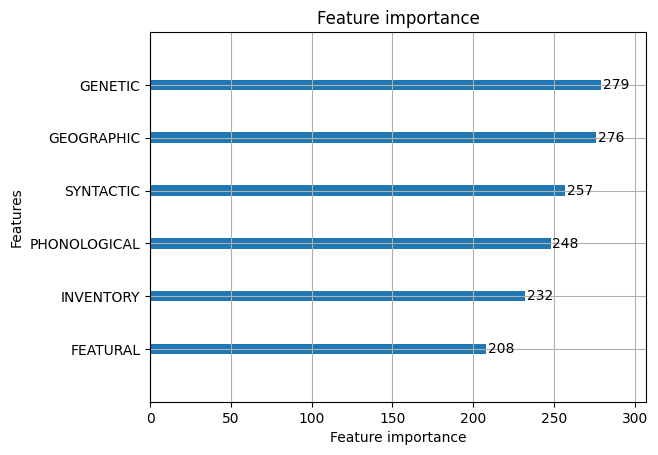

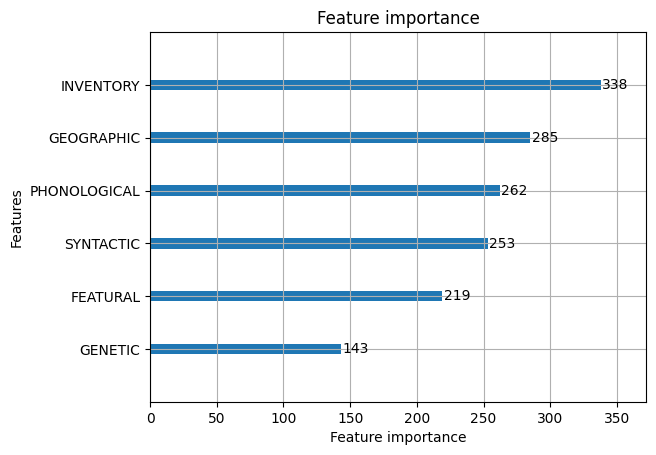

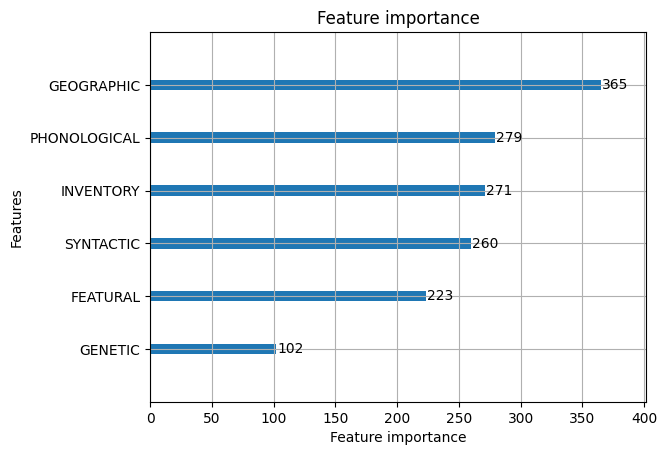

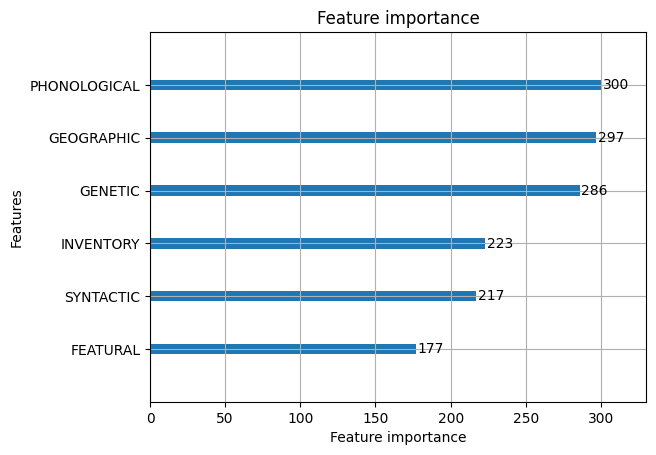

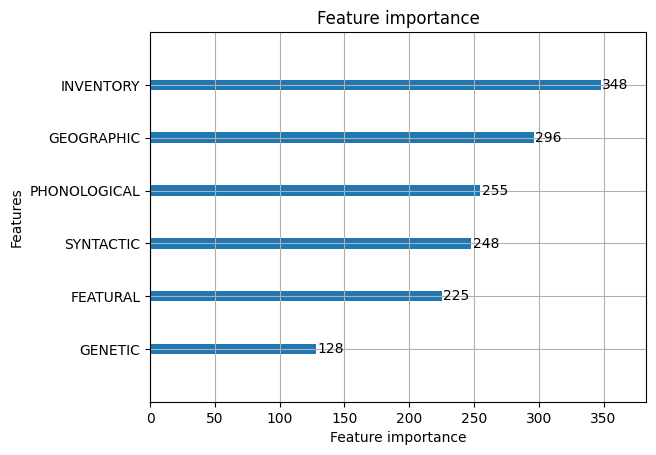

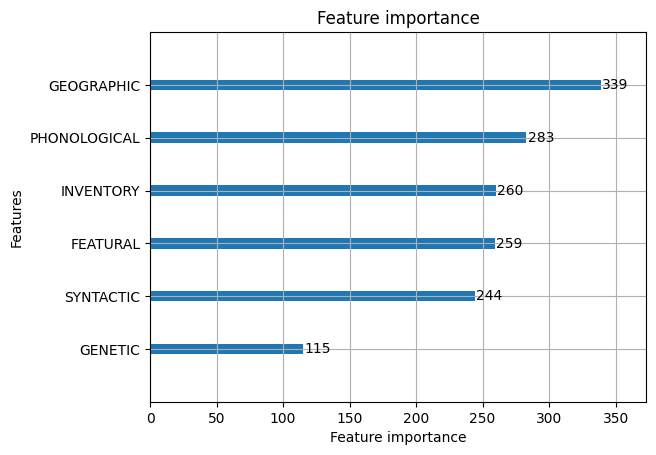

In [3]:
from replace_distances import replace
from dep.dep import dep
from el.el import el
from mt.mt import mt
from pos.pos import pos
import pandas as pd

methods = ['mi', 'phi']
tasks = ['mt', 'dep', 'el', 'pos']

# Change this to 'ALL' to use all sub-task relevant features (incl. distances)
# or 'URIEL' to use only the language distances
FEATURE_SET = 'URIEL'

if FEATURE_SET == 'ALL':
    features_dep = ['Word overlap','Transfer lang dataset size',
                    'Target lang dataset size', 'Transfer over target size ratio', 'Transfer lang TTR',
                    'Target lang TTR', 'Transfer target TTR distance','GENETIC','SYNTACTIC','FEATURAL','PHONOLOGICAL','INVENTORY','GEOGRAPHIC']
    features_el = ['Entity overlap','Transfer lang dataset size','Target lang dataset size',
                    'Transfer over target size ratio','GENETIC','SYNTACTIC','FEATURAL','PHONOLOGICAL','INVENTORY','GEOGRAPHIC']
    features_mt = [
            'Overlap word-level', 'Overlap subword-level', 'Transfer lang dataset size',
            'Target lang dataset size', 'Transfer over target size ratio', 'Transfer lang TTR',
            'Target lang TTR', 'Transfer target TTR distance', 'GENETIC','SYNTACTIC','FEATURAL','PHONOLOGICAL','INVENTORY','GEOGRAPHIC'
        ]
    features_pos = ['Overlap word-level','Transfer lang dataset size','Target lang dataset size','Transfer over target size ratio',
                    'Transfer lang TTR','Target lang TTR','Transfer target TTR distance',
                    'GENETIC','SYNTACTIC','FEATURAL','PHONOLOGICAL','INVENTORY','GEOGRAPHIC']
elif FEATURE_SET == 'URIEL':
    features_dep = ['GENETIC','SYNTACTIC','FEATURAL','PHONOLOGICAL','INVENTORY','GEOGRAPHIC']
    features_el = ['GENETIC','SYNTACTIC','FEATURAL','PHONOLOGICAL','INVENTORY','GEOGRAPHIC']
    features_mt = ['GENETIC','SYNTACTIC','FEATURAL','PHONOLOGICAL','INVENTORY','GEOGRAPHIC']
    features_pos = ['GENETIC','SYNTACTIC','FEATURAL','PHONOLOGICAL','INVENTORY','GEOGRAPHIC']
results = {method: {task: [] for task in tasks} for method in methods}
for method in methods:
    results[method]['num_features'] = []

# baseline
# replace('URIELPlus_Union.csv')
# dep_ndcg = dep('dep/dep_selected.csv', features_dep)
# el_ndcg = el('el/el_selected.csv', features_el)
# mt_ndcg = mt('mt/mt_selected.csv', features_mt)
# pos_ndcg = pos('pos/pos_selected.csv', features_pos)
# results['baseline'] = {
#     'dep': [dep_ndcg],
#     'el': [el_ndcg],
#     'mt': [mt_ndcg],
#     'pos': [pos_ndcg]
# }
# # Save baseline results to CSV
# baseline_df = pd.DataFrame(results['baseline'])
# baseline_df.to_csv('results/baseline_results.csv', index=False)

for method in methods:
    for i in range(100, 701, 100):
        replace(f'selection_result/imputed_ant_{method}_{i}.csv')
        dep_ndcg = dep('dep/dep_selected.csv', features_dep)
        el_ndcg = el('el/el_selected.csv', features_el)
        mt_ndcg = mt('mt/mt_selected.csv', features_mt)
        pos_ndcg = pos('pos/pos_selected.csv', features_pos)
        results[method]['dep'].append(dep_ndcg)
        results[method]['el'].append(el_ndcg)
        results[method]['mt'].append(mt_ndcg)
        results[method]['pos'].append(pos_ndcg)
        results[method]['num_features'].append(i)
        print(f'Finished {method} with {i} features')
    results_df = pd.DataFrame(results[method])
    results_df.set_index('num_features', inplace=True)
    results_df.to_csv(f'results/{method}_results.csv')